In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from pathlib import Path
import json

# GPU: bardziej stabilnie
gpus = tf.config.list_physical_devices('GPU')
for g in gpus:
    try:
        tf.config.experimental.set_memory_growth(g, True)
    except Exception:
        pass
tf.config.optimizer.set_jit(False)  # wyłącz XLA, jeśli robił problemy

import sys
sys.path.append("/home/ciona/projects/RCOLM/data_models/MyModels/")
from mymodels import MyModels
tf.config.set_visible_devices([], 'GPU')
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"   # całkowicie wyłącz GPU

2025-11-03 23:01:23.220093: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2025-11-03 23:01:23.220316: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-11-03 23:01:23.254716: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-11-03 23:01:24.292074: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation or

In [2]:
class MLP_gtzan:

    #method gets dataset_path and it splits it to train and test tables 
    @staticmethod
    def train_test_split_gtzan(gtzan_path, test_size=0.33, random_state=42,
                               extensions={'.png', '.jpg', '.jpeg', '.bmp'}):
        gtzan_root = Path(gtzan_path)
        if not gtzan_root.exists():
            raise FileNotFoundError(f"Ścieżka nie istnieje: {gtzan_root}")

        X, y = [], []
        for genre_dir in sorted([p for p in gtzan_root.iterdir() if p.is_dir() and not p.name.startswith('.')]):
            genre = genre_dir.name
            for img_path in sorted(genre_dir.iterdir()):
                if img_path.is_file() and img_path.suffix.lower() in extensions:
                    X.append(str(img_path))
                    y.append(genre)

        if not X:
            raise ValueError("Nie znaleziono żadnych obrazów z podanymi rozszerzeniami.")

        le = LabelEncoder()
        y_encoded = le.fit_transform(y)
        genre_names = list(le.classes_)

        X_train, X_test, y_train, y_test = train_test_split(
            X, y_encoded,
            test_size=test_size,
            random_state=random_state,
            stratify=y_encoded
        )
        # bezpieczniejszy podgląd
        print(X_train[0], X_test[0], y_test[0])
        return X_train, X_test, y_train, y_test, genre_names

    #method takes path to image directory and then preprecossing it to fit into model
    @staticmethod
    def load_and_preprocess_images(image_paths, target_size=(128, 128)):
        data = []
        for path in image_paths:
            with Image.open(path) as img:
                img = img.convert('RGB').resize(target_size)
                arr = np.asarray(img, dtype=np.float32) / 255.0
                data.append(arr)
        return np.stack(data, axis=0)


    #method for training model on augmented GTZAN dataset 
    @staticmethod
    def CNN_train(X_train, X_test, y_train, y_test, genre_names, model):
        # podgląd
        n_show = min(20, len(X_train))
        plt.figure(figsize=(10, 10))
        for i in range(n_show):
            plt.subplot(5, 5, i + 1)
            plt.xticks([]); plt.yticks([]); plt.grid(False)
            with Image.open(X_train[i]) as img:
                plt.imshow(img)
            plt.xlabel(genre_names[y_train[i]])
        plt.tight_layout(); plt.show()

        X_train_np = MLP_gtzan.load_and_preprocess_images(X_train)
        X_test_np  = MLP_gtzan.load_and_preprocess_images(X_test)
        y_train_np = np.asarray(y_train)
        y_test_np  = np.asarray(y_test)

        # softmax -> from_logits=False
        model.compile(
            optimizer='adam',
            loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
            metrics=['accuracy']
        )

        history = model.fit(
            X_train_np, y_train_np,
            epochs=60,
            batch_size=32,
            validation_data=(X_test_np, y_test_np),
            callbacks=[tf.keras.callbacks.TerminateOnNaN()]
        )

        plt.figure(figsize=(8, 6))
        plt.plot(history.history['accuracy'], label='Train')
        plt.plot(history.history['val_accuracy'], label='Val')
        plt.xlabel('Epoch'); plt.ylabel('Accuracy'); plt.title('Training & Validation')
        plt.legend(); plt.grid(True); plt.show()
        model.summary()
        return model, history

    #MODEL HANDLERS


    # this method takes trained model, classes and save directory. Then it saves the model 
    @staticmethod
    def save_model(model, genre_names, save_dir, image_size=(128, 128)):
        """Zapisuje model Keras + metadane do katalogu."""
        save_dir = Path(save_dir)
        save_dir.mkdir(parents=True, exist_ok=True)

        # model
        model_path = save_dir /"model.keras"
        model.save(model_path)

        # metadane
        meta = {
            "genre_names": list(genre_names),
            "image_width": image_size[0],
            "image_height": image_size[1],
            "expects_softmax": True
        }
        with open(save_dir / "meta.json", "w", encoding="utf-8") as f:
            json.dump(meta, f, ensure_ascii=False, indent=2)

        print(f"✅ Zapisano model do {save_dir.resolve()}")



    #this method takes dir where model is saved, and its returing it with metadata(classes)
    @staticmethod
    def load_model(save_dir):
        """Ładuje model + metadane"""
        save_dir = Path(save_dir)
        model = tf.keras.models.load_model(save_dir, compile=False)
        meta_path = save_dir / "meta.json"
        with open(meta_path, "r", encoding="utf-8") as f:
            meta = json.load(f)
        return model, meta


    # this method takes already saved model, metadata(classes) and melspec path,
    # then it's preprocessing png and predicting the output 
    @staticmethod
    def predict_from_path(model, meta, image_path, top_k=3):
        """Wczytuje jeden obraz, preprocess i zwraca top_k gatunków."""
        w, h = meta.get("image_width", 128), meta.get("image_height", 128)
        genre_names = meta["genre_names"]

    # preprocessing
        with Image.open(image_path) as img:
            img = img.convert("RGB").resize((w, h))
            arr = np.asarray(img, dtype=np.float32) / 255.0
        arr = np.expand_dims(arr, axis=0)  # batch=1

    # predykcja
        probs = model.predict(arr, verbose=0)[0]

        idx_sorted = np.argsort(probs)[::-1]
        results = [(genre_names[i], float(probs[i])) for i in idx_sorted[:top_k]]
        return results

/home/ciona/projects/RCOLM/data/converted_data/GTZAN/hiphop/hiphop.00078_TS.png /home/ciona/projects/RCOLM/data/converted_data/GTZAN/metal/metal.00029_pitch.png 6


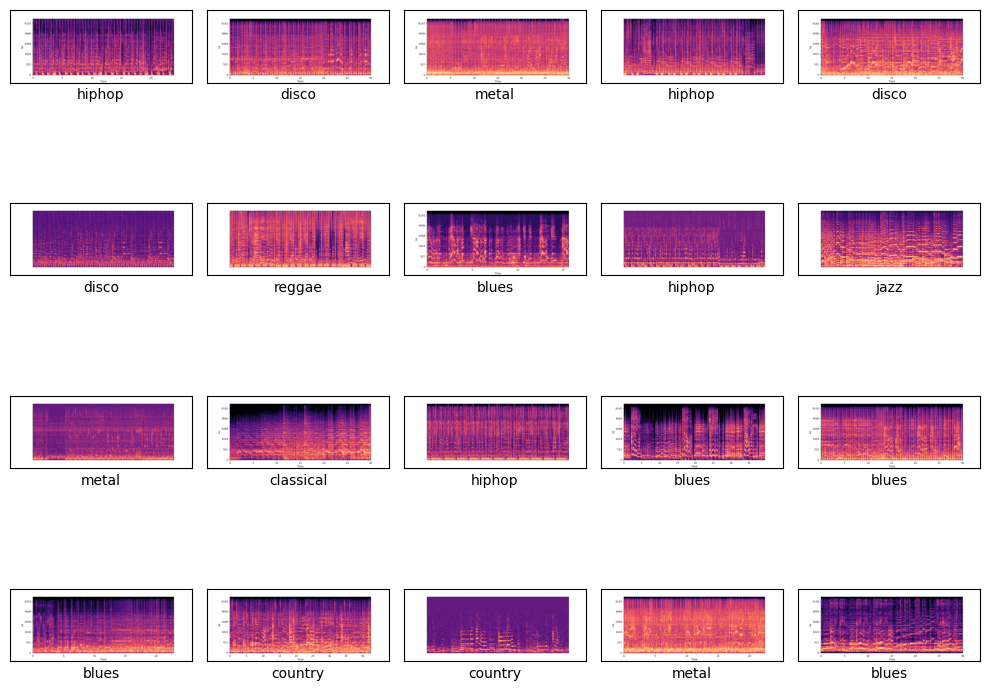

KeyboardInterrupt: 

In [18]:
gtzan_path = "/home/ciona/projects/RCOLM/data/converted_data/GTZAN/"
save_dir =  "/home/ciona/projects/RCOLM/data_models/saved/gtzan_v1"
image_path = "/home/ciona/projects/RCOLM/tests/png/blue_train.png"

X_train, X_test, y_train, y_test, genre_names = MLP_gtzan.train_test_split_gtzan(gtzan_path)
num_classes = len(genre_names)
model = MyModels.CNN_model(num_classes)
model, history = MLP_gtzan.CNN_train(X_train, X_test, y_train, y_test, genre_names, model)
#MLP_gtzan.save_model(model, genre_names, save_dir)
# model, meta = MLP_gtzan.load_model(save_dir)
# MLP_gtzan.predict_from_path(model, meta, image_path)